# Transmission plotter - multiple materials

Maggie Tseng  
Last updated: Apr 15, 2026

Also see version attached to: [elog:Pa229/257](https://elog.frib.msu.edu/Pa229/257)

This notebook plots EUV photon transmission through a material-dependent distance as a function of EUV photon energy for different materials.

The minimum distance that the EUV photon must travel through is set to the mean implantation depth of a U-229 ion in the material of interest. That mean implantation depth is determined using a SRIM output file.

The transmission for EUV photons across a range of possible photon energies is calculated using the attenuation lengths given by Henke et al.

Henke data at: https://henke.lbl.gov/optical_constants/atten2.html  
(enter material name/chem formula, density -1 to use tabulated values, scan photon range from 30 to 150 in 100 steps)

Transmission equation: fraction of surviving photons = exp(- (dist traveled by photon) / (attentuation length for that photon energy)), which can be written: 
$$T = \exp(-x/ \ell)$$

<!-- for more on this equation, see MJT-LB2/80, or really any textbook discussing gamma/x-ray/photon attenuation -->

Units in this notebook: unless specified otherwise, 
- energies are in MeV
- lengths are in microns

Manual format adjustments needed for input files (so far):

Note that the text files provided by Henke must be slightly modified by hand to be used here: put two spaces (instead of comma + space) between the header labels in the second line.  

The output from SRIM must also be lightly edited by hand: delete all lines except the headers, spacing lines, and numbers, then make sure each section of dashes is separated by two spaces.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Note: numpy has a useful built-in interpolation function.  
https://numpy.org/doc/stable/reference/generated/numpy.interp.html 

## Function 1:  
Given the material and the chosen beam energy, determine the mean implantation depth (single value).

In [3]:
def get_mean_impl_depth(material_shortname, beam_energy):
    filepath = f"SRIM_data/U229_{material_shortname}.txt"
    df_impl = pd.read_csv(filepath, header=None, usecols=[0,3], 
                          names=["ion_energy","mean_impl_dist"],
                          sep='[ ]{2,}', engine="python")
    ion_energy = np.array( df_impl["ion_energy"][3:].str.replace(r'\D\.?\D', '', regex=True).astype(float) )
    mean_impl_depth = 1e-4 * np.array( df_impl["mean_impl_dist"][3:].str.replace(r'\D\.?\D', '', regex=True).astype(float) )
    mean_impl_depth_val = round( np.interp(beam_energy, ion_energy, mean_impl_depth), 3)
    return mean_impl_depth_val

## Function 2:  
Given the material's attenuation length as a func of photon energy (array), as well as the minimum distance that the photon must travel through (mean impl depth is a single value), determine the transmission as a function of photon energy (array).

In [4]:
def get_attn_length(material_shortname):
    filepath = f"Henke_data/xray_{material_shortname}.dat"
    df_material = pd.read_csv(filepath, header=1, sep="  ", engine="python")
    df_material.rename(columns={'Photon Energy (eV)': 'energy', 'Atten Length (microns)': 'attn_length'}, inplace=True)
    photon_energy = df_material["energy"]
    attn_length = df_material["attn_length"]
    photon_energy_vs_attn_length = np.zeros([len(photon_energy),2])
    photon_energy_vs_attn_length[:,0] = photon_energy
    photon_energy_vs_attn_length[:,1] = attn_length
    return photon_energy_vs_attn_length

def get_transmission(dist, attn_length):
    transmission_val = np.exp(-1 * dist / attn_length)
    return transmission_val

## Function 3:  
Plot the transmission (array) as a function of photon energy (array) for a given beam energy (single value).

In [5]:
# loop across range of beam energies
# todo - maybe make photon energy range an argument?
def add_material_t(material_shortname, beam_energy):
    mat_mean_impl_depth = get_mean_impl_depth(material_shortname, beam_energy)
    # mat_mean_impl_depth = 0.333 # for comparison against gamma_transmission_plotter_multiple, see elog:Pa229/135
    mat_photon_energy_vs_attn_length = get_attn_length(material_shortname)
    mat_photon_energy = mat_photon_energy_vs_attn_length[:,0]
    mat_attn_length = mat_photon_energy_vs_attn_length[:,1]
    mat_transmission = get_transmission(mat_mean_impl_depth, mat_attn_length)
    mat_label = label=f"{material_shortname}, {mat_mean_impl_depth} um"
    # print(mat_transmission)
    ax_t.plot(mat_photon_energy, mat_transmission, label=mat_label)
    print(f"Material added: {mat_label}")


## Function 4 (auxiliary)  

This function allows us to check a single point, so that we can answer the following question:  
- Given the material, implantation depth in microns (which we'll have to calculate separately by hand based on TBE), and photon energy in eV, what is the transmission?

In [6]:
def check_transmission(material_shortname, impl_depth_val, photon_energy):
    # (could optionally rewrite to use material and TBE to get impl_depth)
    # use material and photon energy to get attn_length
    attn_length_val = np.interp( photon_energy, get_attn_length(material_shortname)[:,0], get_attn_length(material_shortname)[:,1] )
    transmission_val = get_transmission(impl_depth_val, attn_length_val)
    return transmission_val

In [7]:
check_transmission("Be", 0.2431, 60.2571)
# the result, 0.5982, exactly matches my calculation done by hand (MJT-LB3/153)

0.5982379681547199

## Plot the transmission for several materials

The following three plots use beam energies corresponding to 10 KV, 20 KV, and 30 KV respectively.  

I have chosen the following elements to cover a range of Z values:
- beryllium, Z=4
- copper, Z=29
- tin, Z=50
- lead, Z=82

Material added: Be, 0.227 um
Material added: Cu, 0.076 um
Material added: Sn, 0.11 um
Material added: Pb, 0.091 um


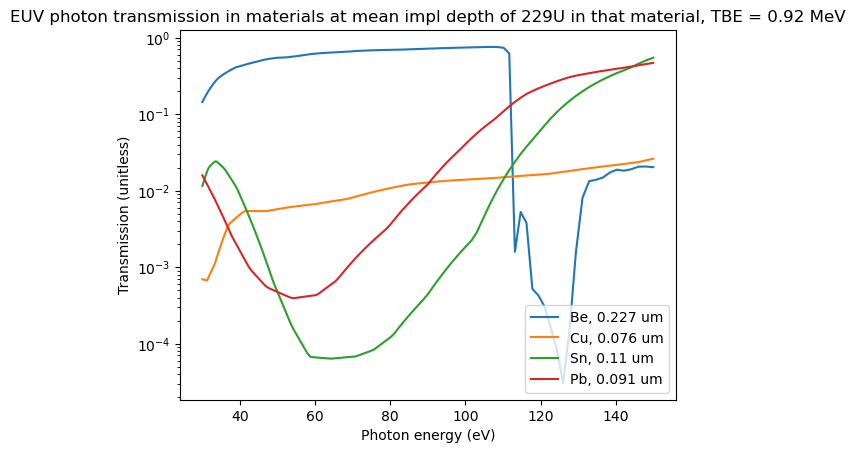

In [33]:
charge_state = 92
FRIB_potential = 10 # KV
# total_beam_energy = 0.92 # 0.92 MeV corresponds to 10 KV beam if ion is fully stripped (92+)
total_beam_energy = charge_state * FRIB_potential / 1e3 # MeV

fig_t, ax_t = plt.subplots();
ax_t.set_title(f"EUV photon transmission in materials at mean impl depth of 229U in that material, TBE = {total_beam_energy} MeV")
ax_t.set_xlabel("Photon energy (eV)")
ax_t.set_ylabel("Transmission (unitless)")
ax_t.set_yscale("log")
# ax_t.set_ylim(1e-13,1e0)

add_material_t("Be", total_beam_energy)
add_material_t("Cu", total_beam_energy)
add_material_t("Sn", total_beam_energy)
add_material_t("Pb", total_beam_energy)

ax_t.legend();

Material added: Be, 0.414 um
Material added: Cu, 0.142 um
Material added: Sn, 0.205 um
Material added: Pb, 0.171 um


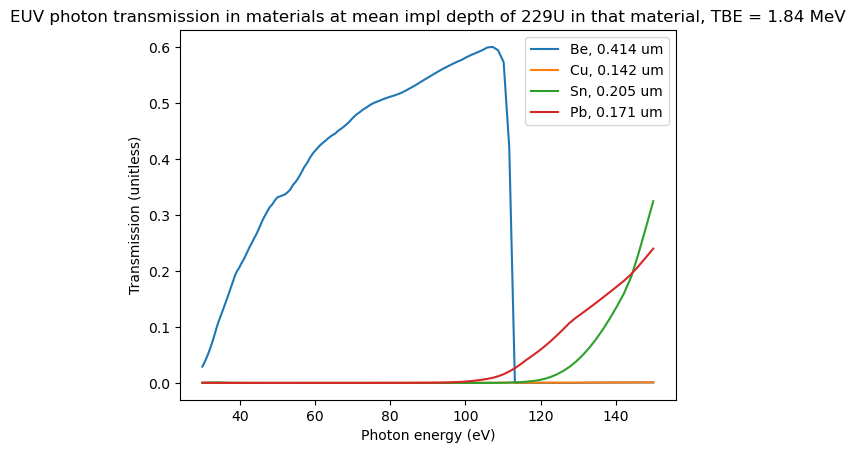

In [26]:
charge_state_2 = 92
FRIB_potential_2 = 20 # KV
# total_beam_energy_2 = 1.84 # 1.84 MeV corresponds to 20 KV beam if ion is fully stripped (92+)
total_beam_energy_2 = charge_state_2 * FRIB_potential_2 / 1e3 # MeV

fig_t, ax_t = plt.subplots();
ax_t.set_title(f"EUV photon transmission in materials at mean impl depth of 229U in that material, TBE = {total_beam_energy_2} MeV")
ax_t.set_xlabel("Photon energy (eV)")
ax_t.set_ylabel("Transmission (unitless)")
# ax_t.set_yscale("log")
# ax_t.set_ylim(1e-13,1e0)

add_material_t("Be", total_beam_energy_2)
add_material_t("Cu", total_beam_energy_2)
add_material_t("Sn", total_beam_energy_2)
add_material_t("Pb", total_beam_energy_2)

ax_t.legend();

Material added: Be, 0.603 um
Material added: Cu, 0.212 um
Material added: Sn, 0.304 um
Material added: Pb, 0.255 um


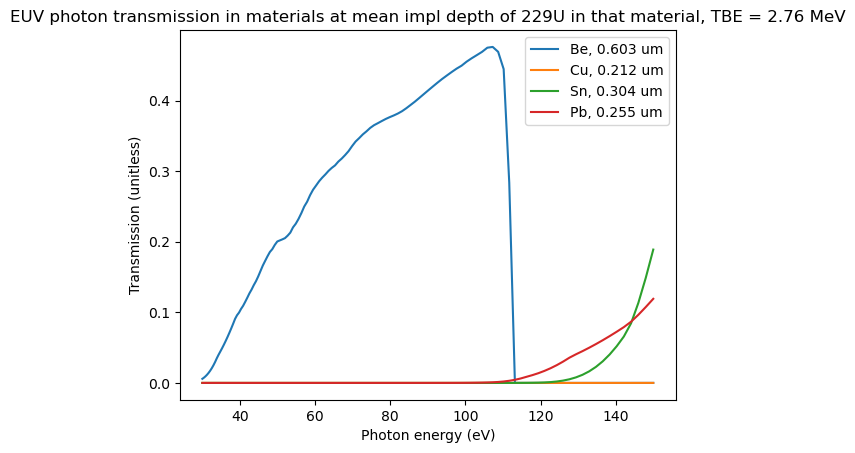

In [30]:
charge_state_3 = 92
FRIB_potential_3 = 30 # KV
# total_beam_energy_3 = 2.76 # MeV, corresponds to 30 KV beam if ion is fully stripped (92+)
total_beam_energy_3 = charge_state_3 * FRIB_potential_3 / 1e3 # MeV

fig_t, ax_t = plt.subplots();
ax_t.set_title(f"EUV photon transmission in materials at mean impl depth of 229U in that material, TBE = {total_beam_energy_3} MeV")
ax_t.set_xlabel("Photon energy (eV)")
ax_t.set_ylabel("Transmission (unitless)")
# ax_t.set_yscale("log")
# ax_t.set_ylim(1e-13,1e0)

add_material_t("Be", total_beam_energy_3)
add_material_t("Cu", total_beam_energy_3)
add_material_t("Sn", total_beam_energy_3)
add_material_t("Pb", total_beam_energy_3)

ax_t.legend();

---

Thoughts and checks

- todo - get these plots for much lower beam energies (e.g. 92+ at 10 KV is 0.92 MeV, but 1+ at 10 KV is 10 keV) - need to pull info for this larger data range from SRIM, and if the current files don't give reasonable result, the output should state this explicitly in some way
- manual check of implantation into 0.2431 microns of Be (TBE = 1 MeV)
- OOM of T looks very different from the 0.333 um implantation case
- in beryllium case, if we set impl depth to 0.333 um, then we get the same result as in `gamma_transmission_plotter_multiple.ipynb`, which suggests that small changes in the impl depth are very important!

Compare implantation depths calculated with LISE++ and SRIM, since I suspect these are actually pretty different...

1. implantation of 229U into Pb at TBE = 2.76 MeV (30 KV)...
    - LISE++: mean impl depth is 0.33252 um, stdev is 0.008 um
    - SRIM: mean impl depth is 0.2549 um, long. straggling is 0.1049 um
      <!-- lat. straggling is 0.726 um -->
    - the mean impl depth is very different! (SRIM/LISE ratio: 0.76)

2. implantation of 229U into Cu at TBE = 2.76 MeV (30 KV)...
    - LISE++: mean impl depth 0.23086 um, stdev 4.256e-03 um
    - SRIM: mean impl depth is 0.2117 um, long. straggling is 0.0455 um
      <!-- lat. straggling is 0.368 um -->
    - mean impl depth is somewhat different. (SRIM/LISE ratio: 0.91)

3. implantation of 229U into Be at TBE = 2.76 MeV (30 KV)...
    - LISE++: mean impl depth is 0.71446 um, stdev 1.032e-02 um
    - SRIM: mean impl depth is 0.6028 um, long. straggling is 0.0404 um
      <!-- lat. straggling is 0.386 um -->
    - mean impl depth is somewhat different. SRIM/LISE ratio: 0.84

4. implantation of 229U into Pb at TBE = 0.92 MeV (10 KV)...
    - LISE++: mean impl depth 0.12030 um, stdev 7.682e-03 um
    - SRIM: mean impl depth is 0.0913 um, long. straggling is 0.0427 um
      <!-- lat. straggling 308 A -->
    - mean impl depth is very different! (SRIM/LISE ratio: 0.76)

From these few calculations, it looks like SRIM calculated implantation depth is consistently smaller than LISE++ calculated implantation depth. No clear trend in the difference based on Z of target or TBE, but it seems like results are more different for implantation into lead.

In [10]:
0.2549/0.3352 # into Pb at 30 KV, SRIM value divided by LISE value
0.2117/0.23086 # into Cu at 30 KV, SRIM val divided by LISE val
0.6028/0.71446 # into Be at 30 KV, SRIM/LISE
0.0913/0.12030 # into Pb at 10 KV, SRIM/LISE

0.7589359933499584

In [19]:
# Compare transmission through Be for photon energy of 60 eV?
print(check_transmission("Be", 0.33252, 60) ) # LISE
print(check_transmission("Be", 0.2549, 60) ) # SRIM

0.49336689321933946
0.581826096901346
